# I-DEAS universal files: meshes, groups and results as steps

The I-DEAS Universal File (`.unv`, and `.uff` for test-lab data) is the neutral format of Salome, Code_Aster, gmsh, NX and experimental-modal-analysis rigs. Since v15.6.0 meshio++ reads it as those tools write it: quadratic node orders pinned against gmsh and Salome, permanent groups as named [regions](../../doc/regions.md), and every result (a mode, a time, a frequency line of a measured FRF) as one step of a [sequence](../../doc/sequences.md). The files below are the test fixtures, written by gmsh and pyuff. See [the format page](../../doc/formats/unv.md).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

TMP = tempfile.mkdtemp()
FIXTURES = os.path.join('..', '..', 'tests', 'python', 'meshes', 'unv')


def to_grid(mesh):
    """meshio++ Mesh -> PyVista grid via a temporary .vtu."""
    path = os.path.join(TMP, 'render.vtu')
    mp.write(path, mesh)
    return pv.read(path)


def gallery(items, ncols=2, size=(760, 500)):
    """Render `(mesh, scalar, title, camera)` items side by side, or with matplotlib when GL is unavailable."""
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(6.0 * ncols, 4.6 * nrows))
    for k, (mesh, scalar, title, camera) in enumerate(items, start=1):
        ax = fig.add_subplot(nrows, ncols, k)
        try:
            grid = to_grid(mesh)
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalar, cmap='turbo', show_edges=True, edge_color='#333333',
                        line_width=0.8, scalar_bar_args={'title': scalar, 'vertical': False,
                                                        'position_x': 0.2, 'position_y': 0.02, 'width': 0.6})
            pl.camera_position = camera
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = mesh.points
            values = mesh.cell_data[scalar][0] if scalar in mesh.cell_data else mesh.point_data[scalar]
            values = np.linalg.norm(values, axis=1) if values.ndim > 1 else values
            if len(values) == len(p):
                ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8, c=values, cmap='turbo')
            else:
                ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8, c='steelblue')
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Quadratic meshes and their groups

gmsh wrote this tetrahedral box, and the same mesh as `.msh`. The `.unv` lists each tetrahedron's mid-edge nodes between its corners; meshio++ reorders them, and each gmsh physical group comes back as a point region (its nodes) and a cell region (its elements), tagged with the group number.

[('triangle6', 28), ('tetra10', 100)]
[('sides', 'point', 31, 74), ('volume', 'point', 30, 231), ('sides', 'cell', 31, 28), ('volume', 'cell', 30, 100)]


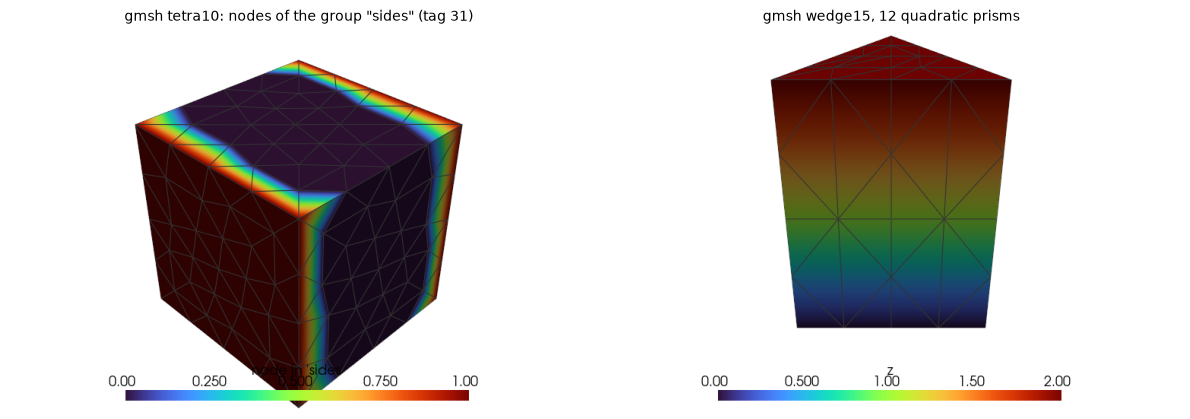

In [2]:
tet = mp.read(os.path.join(FIXTURES, 'gmsh_tet10.unv'))
print([(c.type, len(c.data)) for c in tet.cells])
print([(r.name, r.kind, r.tag, len(r.entries)) for r in tet.regions])

# Colour the nodes of the 'sides' group (the two faces gmsh tagged 31).
sides = next(r for r in tet.regions if r.name == 'sides' and r.kind == 'point')
on_sides = np.zeros(len(tet.points))
on_sides[sides.entries] = 1.0
shown = mp.Mesh(tet.points, [c for c in tet.cells if c.type == 'tetra10'], point_data={"node in 'sides'": on_sides})

# The wedge15 mesh: every mid-edge node sits on its edge, so colour by height.
wedge = mp.read(os.path.join(FIXTURES, 'gmsh_wedge15.unv'))
wedge = mp.Mesh(wedge.points, wedge.cells, point_data={'z': wedge.points[:, 2].copy()})
gallery([(shown, "node in 'sides'", 'gmsh tetra10: nodes of the group "sides" (tag 31)', 'iso'),
         (wedge, 'z', 'gmsh wedge15, 12 quadratic prisms', 'iso')])

## Mode shapes as a sequence

`modes_2414.unv` holds three normal modes of a displacement (dataset 2414, analysis type 2) and a static stress. Each is a step: `read_metadata` lists the step values (the modal frequencies, then the static load set) and `time_step` picks one. Below, each mode's displacement warps the mesh.

steps: [12.5, 31.0, 47.25, 1.0]


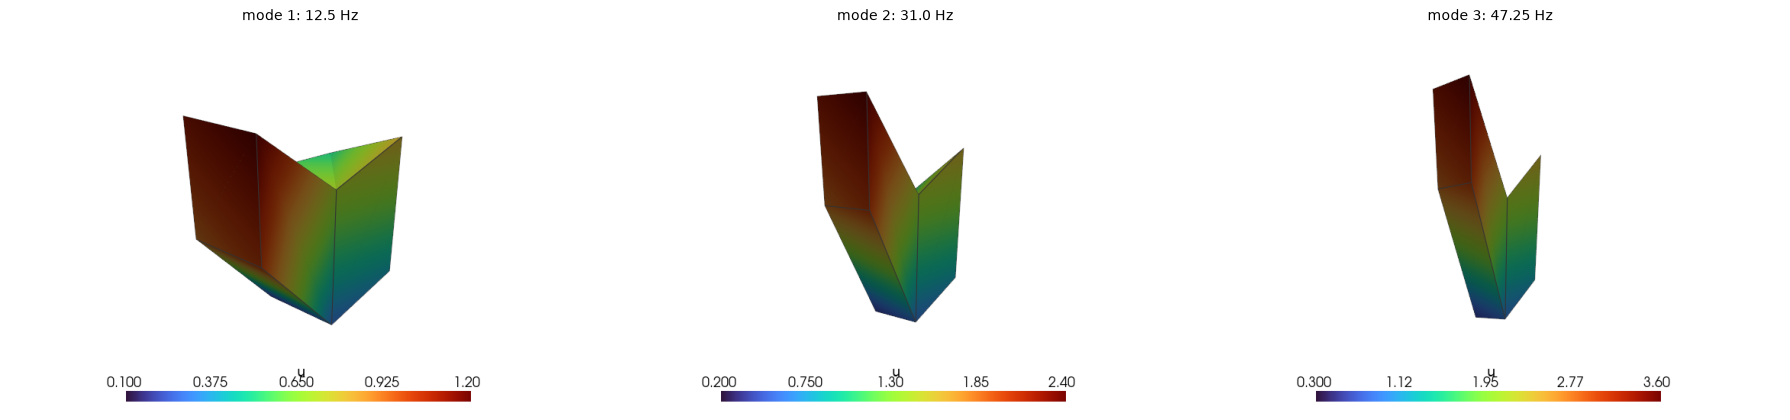

static stress (xx yy zz xy yz zx): [[1.0, 2.0, 3.0, 4.0, 5.0, 6.0], [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]]


In [3]:
path = os.path.join(FIXTURES, 'modes_2414.unv')
print('steps:', mp.read_metadata(path)['time_values'])
items = []
for k in range(3):
    mode = mp.read(path, time_step=k)
    disp = mode.point_data['Mode shape']
    warped = mp.Mesh(mode.points + 2.0 * disp, mode.cells, point_data={'|u|': np.linalg.norm(disp, axis=1)})
    items.append((warped, '|u|', f"mode {mode.field_data['unv:step'][0]}: {mode.field_data['meshio:time'][0]} Hz", 'iso'))
gallery(items, ncols=3)

static = mp.read(path, time_step=-1)
print('static stress (xx yy zz xy yz zx):', static.cell_data['stress'][0].tolist())

## Measured FRFs (dataset 58) as a frequency sequence

A test-lab `.uff` file holds one dataset 58 per measured function. meshio++ groups the functions of one kind on one frequency grid, and each frequency is a step whose `point_data` holds the complex response at every response node: `frf_real` / `frf_imag`, 3 components for the X/Y/Z directions. `pyuff_frf_58b.uff` stores the same functions in binary (58b).

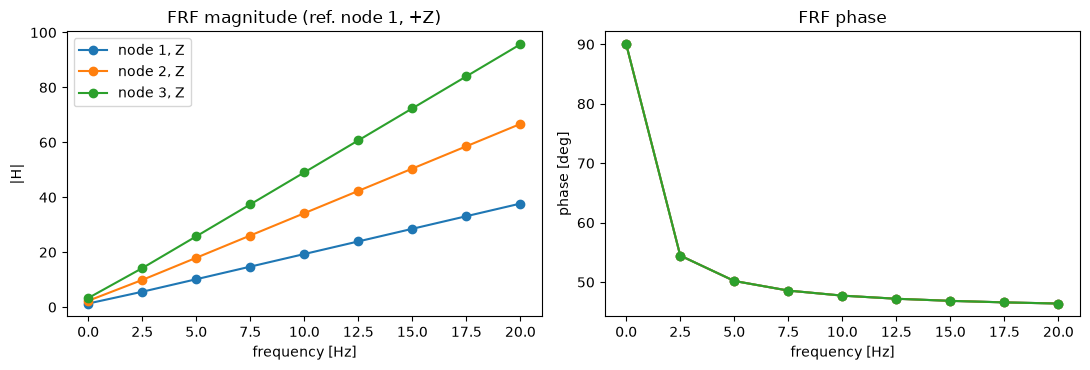

58 and 58b agree: True


In [4]:
uff = os.path.join(FIXTURES, 'pyuff_frf_58b.uff')
freqs, h = [], []
for f, step in mp.read_sequence(uff):
    freqs.append(f)
    h.append(step.point_data['frf_real'] + 1j * step.point_data['frf_imag'])
h = np.array(h)  # (frequency, node, direction)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for node in range(3):
    ax[0].plot(freqs, np.abs(h[:, node, 2]), marker='o', label=f'node {node + 1}, Z')
    ax[1].plot(freqs, np.degrees(np.angle(h[:, node, 2])), marker='o')
ax[0].set(xlabel='frequency [Hz]', ylabel='|H|', title='FRF magnitude (ref. node 1, +Z)')
ax[1].set(xlabel='frequency [Hz]', ylabel='phase [deg]', title='FRF phase')
ax[0].legend()
plt.tight_layout()
plt.show()

ascii_ = mp.read(os.path.join(FIXTURES, 'pyuff_frf.uff'), time_step=4)
binary = mp.read(uff, time_step=4)
print('58 and 58b agree:', np.allclose(ascii_.point_data['frf_real'], binary.point_data['frf_real']))

## Writing groups and a result step

On write, point and cell regions become 2467 groups (a point and a cell region sharing a name are one group, numbered by the region's tag), and `point_data` / `cell_data` become 2414 results of one step described by `unv:analysis`, `unv:step` and `meshio:time`.

regions: [('face', 'cell', 11), ('face', 'point', 11), ('solid', 'cell', 10), ('solid', 'point', 10)]
step: {'meshio:time': [0.35], 'unv:analysis': [4], 'unv:step': [7]}
    -1
  2467
        10         0         0         0         0         0         0        89
solid
         7         1         0         0         7         2         0         0
         7         3         0         0         7         4         0         0
    


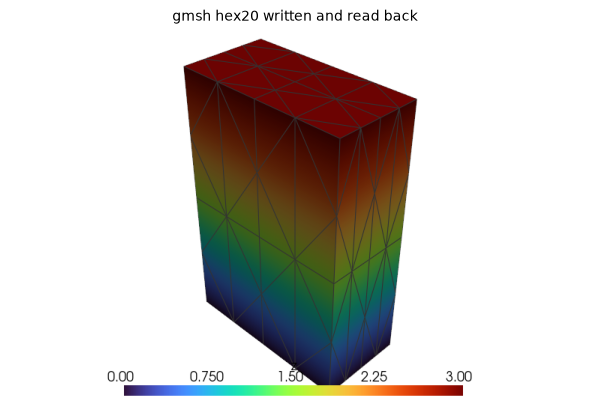

In [5]:
hexes = mp.read(os.path.join(FIXTURES, 'gmsh_hex20.unv'))
hexes.point_data = {'z': hexes.points[:, 2].copy()}
hexes.field_data = {'unv:analysis': np.array([4]), 'unv:step': np.array([7]), 'meshio:time': np.array([0.35])}
out = os.path.join(TMP, 'written.unv')
mp.write(out, hexes)
back = mp.read(out)
print('regions:', sorted((r.name, r.kind, r.tag) for r in back.regions))
print('step:', {k: v.tolist() for k, v in back.field_data.items()})
text = open(out).read()
i = text.index('  2467')
print(text[i - 7:i + 260])
gallery([(back, 'z', 'gmsh hex20 written and read back', 'iso')], ncols=1)